# Avance 3 — Baseline de Modelo  
## Monitoreo de estrés hídrico en parcelas aguacateras con Sentinel‑2

Este notebook construye un **modelo baseline** a partir del dataset final generado en el Avance 2 de Feature Engineering.

El objetivo es establecer una primera referencia cuantitativa para evaluar si el problema es viable con modelos simples antes de invertir tiempo en modelos más avanzados como Random Forest, XGBoost, CNNs o arquitecturas multitemporales.

---

## Objetivos del avance

**a) Establecer las medidas de calidad del modelo de aprendizaje automático.**

**b) Proporcionar un marco de referencia para evaluar y mejorar modelos más avanzados.**

---

## Preguntas guía

1. ¿Qué algoritmo se puede utilizar como baseline para predecir la variable objetivo?
2. ¿Se puede determinar la importancia de las características?
3. ¿El modelo está subajustando o sobreajustando?
4. ¿Cuál es la métrica adecuada para el problema de negocio?
5. ¿Cuál debería ser el desempeño mínimo a obtener?

---

## Contexto del problema

La variable objetivo es `stress_class`, una etiqueta preliminar de posible estrés hídrico:

| Clase | Significado |
|---|---|
| `no_relative_stress` | Sin estrés relativo |
| `moderate_possible_stress` | Posible estrés moderado |
| `severe_possible_stress` | Posible estrés severo |

**Nota importante:** esta etiqueta se deriva de NDMI y todavía no corresponde a mediciones agronómicas de campo. Por lo tanto, los resultados se interpretan como una evaluación inicial de viabilidad, no como diagnóstico definitivo.

# 1. Librerías

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 120

# 2. Carga del dataset final

Este notebook espera encontrar el archivo `df_fe_avance2.csv`, que fue generado en el Avance 2.

Se buscan varias rutas comunes para facilitar la ejecución en diferentes computadoras.

In [2]:
# ============================================================
# 2. Load final FE dataset
# ============================================================

CANDIDATE_PATHS = [
    Path("df_fe_avance2.csv"),
    Path("data/csv/df_fe_avance2.csv"),
    Path("data/processed/df_fe_avance2.csv"),
    Path("data/processed/feature_engineering/df_fe_avance2.csv"),
    Path("data/processed/feature_engineering_combined/df_fe_avance2.csv"),
    Path(r"C:\Users\omarh\Desktop\Maestria\avocado_project\data\csv\df_fe_avance2.csv"),
    Path(r"C:\Users\omarh\Desktop\Maestria\avocado_project\data\processed\df_fe_avance2.csv"),
]

DATA_PATH = None

for path in CANDIDATE_PATHS:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró df_fe_avance2.csv. "
        "Coloca el archivo en la misma carpeta del notebook o actualiza CANDIDATE_PATHS."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset cargado desde:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

print("\\nColumnas:")
print(list(df.columns))

Dataset cargado desde: df_fe_avance2.csv
Shape: (4000, 63)


,name,date,year,month,stress_class,stress_label,NDMI_sc,NDMI_roll3_sc,NDMI_raster_max_sc,NDVI_sc,NDVI_roll3_sc,NDMI_lag2_sc,NDVI_lag1_sc,NDVI_raster_max_sc,B11_mean_sc,B8_mean_sc,mes_sin_sc,NDVI_lag2_sc,ratio_vi_hum_log_sc,NDVI_raster_std_sc,B11_max_sc,B11_min_sc,lat_kml_sc,B8_max_sc,NDMI_raster_std_sc,mes_cos_sc,image_count_sc,NDMI_raster_min_sc,NDVI_raster_min_sc,lon_kml_sc,NDMI_delta_yj_sc,B8_min_sc,B8_std_sc,B2_valid_ratio_sc,B11_std_sc,NDVI_delta_yj_sc,NDWI_proxy_sc,B2_std_sc,B2_max_sc,B2_min_sc,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,FA1,FA2,FA3,FA4,FA5
0,H1,2023-01-01,2023,1,moderate_possible_stress,1,-1.022531,-1.132622,0.156160,-1.366467,-1.568217,1.208583e-16,0.000000,0.337331,-0.142837,-1.113141,0.585722,0.000000,-0.270025,0.641174,2.075593,-0.427343,2.806674,1.110292,0.435136,1.217759,-0.645978,-0.104380,-1.213554,0.455801,0.087816,-0.370521,1.710315,0.783589,0.717329,0.066570,-0.729059,2.753569,1.921357,-0.440269,-2.610105,0.327108,3.193773,-0.803899,2.118352,2.795608,-0.636022,1.606305,0.449738,0.140974,-1.409990,1.406630,0.846457,0.097574,-0.792891,0.678830,-0.177915,-0.135962,1.363864,0.084364,0.157333,-1.950609,-1.538202
1,H1,2023-02-01,2023,2,severe_possible_stress,2,-1.393120,-1.335875,-0.713439,-1.940279,-1.895365,1.208583e-16,-1.389291,-0.372775,0.301920,-1.167122,1.097147,0.000000,-0.956623,-0.443114,1.978533,-0.008975,2.806674,0.945555,0.417735,0.689877,0.555841,-0.040368,-1.046670,0.455801,-0.603016,-0.193583,1.305946,0.783589,0.546006,-0.691868,-1.109866,2.418618,1.738484,-0.341944,-4.128391,-0.521999,2.227207,-1.688979,1.909036,2.168197,-1.095989,1.796424,-0.441182,-0.200606,-0.586760,1.187737,0.808493,0.427579,-1.025476,0.938050,-0.278326,-0.885300,1.930918,0.208010,-0.141508,-1.803538,-1.095780
2,H1,2023-03-01,2023,3,severe_possible_stress,2,-1.660000,-1.501208,-0.743550,-2.095917,-2.063570,-1.085464e+00,-1.969428,-0.950365,0.644253,-1.189442,1.284342,-1.413198,-1.209792,-0.882409,2.143601,0.251300,2.806674,0.946575,0.628589,-0.031225,0.555841,0.020706,-1.129276,0.455801,-0.395610,-0.095621,1.300176,0.783589,0.781794,-0.121222,-1.001914,2.185271,1.723011,-0.141845,-5.652109,-0.612983,1.983246,-0.640189,1.735721,1.978762,-0.920150,1.688520,-0.779617,-0.411811,-0.547209,1.164463,0.223363,0.513019,-1.177690,0.834673,-0.524522,-1.055979,2.100751,-0.008067,0.096265,-1.579355,-0.857489
3,H1,2023-04-01,2023,4,severe_possible_stress,2,-1.676947,-1.740489,-0.789239,-2.269056,-2.406633,-1.467405e+00,-2.126781,-0.849284,1.162042,-0.892973,1.097147,-1.999392,-1.295650,-1.092250,2.409691,0.448916,2.806674,1.105192,0.323060,-0.752326,0.555841,0.091976,-1.120371,0.455801,0.077651,0.051701,1.244376,0.783589,0.901813,-0.144289,-1.237281,2.417550,1.866495,-0.126321,-6.742060,-0.071438,1.905303,-0.181508,1.684509,1.675235,-0.955637,1.534679,-0.846324,-0.363302,-0.644930,1.149354,0.320082,0.322247,-0.876757,0.476886,-0.897147,-1.163643,2.262711,0.171589,0.581382,-1.298962,-0.811853
4,H1,2023-05-01,2023,5,severe_possible_stress,2,-1.783765,-1.883325,-0.485297,-2.250137,-2.524407,-1.742461e+00,-2.301829,-0.494710,1.364435,-0.851409,0.585722,-2.158389,-1.341357,-1.003904,2.620319,0.500007,2.806674,1.262279,0.320549,-1.280209,0.555841,0.143143,-1.087042,0.455801,-0.088270,0.039551,1.449577,0.783589,1.134112,0.104981,-1.073580,2.454803,2.046554,-0.026271,-7.036269,0.215540,2.251893,0.395587,1.910089,1.462206,-1.075454,1.671697,-0.758910,-0.542972,-0.465360,0.976503,0.064313,0.124856,-0.822966,0.275873,-1.042999,-1.258477,2.255483,-0.011091,0.901705,-1.116866,-0.992226


\nColumnas:
['name', 'date', 'year', 'month', 'stress_class', 'stress_label', 'NDMI_sc', 'NDMI_roll3_sc', 'NDMI_raster_max_sc', 'NDVI_sc', 'NDVI_roll3_sc', 'NDMI_lag2_sc', 'NDVI_lag1_sc', 'NDVI_raster_max_sc', 'B11_mean_sc', 'B8_mean_sc', 'mes_sin_sc', 'NDVI_lag2_sc', 'ratio_vi_hum_log_sc', 'NDVI_raster_std_sc', 'B11_max_sc', 'B11_min_sc', 'lat_kml_sc', 'B8_max_sc', 'NDMI_raster_std_sc', 'mes_cos_sc', 'image_count_sc', 'NDMI_raster_min_sc', 'NDVI_raster_min_sc', 'lon_kml_sc', 'NDMI_delta_yj_sc', 'B8_min_sc', 'B8_std_sc', 'B2_valid_ratio_sc', 'B11_std_sc', 'NDVI_delta_yj_sc', 'NDWI_proxy_sc', 'B2_std_sc', 'B2_max_sc', 'B2_min_sc', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'FA1', 'FA2', 'FA3', 'FA4', 'FA5']


# 3. Revisión de estructura y variable objetivo

Antes de modelar se confirma:

- número de observaciones,
- número de columnas,
- distribución de clases,
- existencia de valores faltantes.

Shape: (4000, 63)

Distribución de clases:


,stress_class,count,percentage
0,no_relative_stress,3000,75.0
1,moderate_possible_stress,600,15.0
2,severe_possible_stress,400,10.0


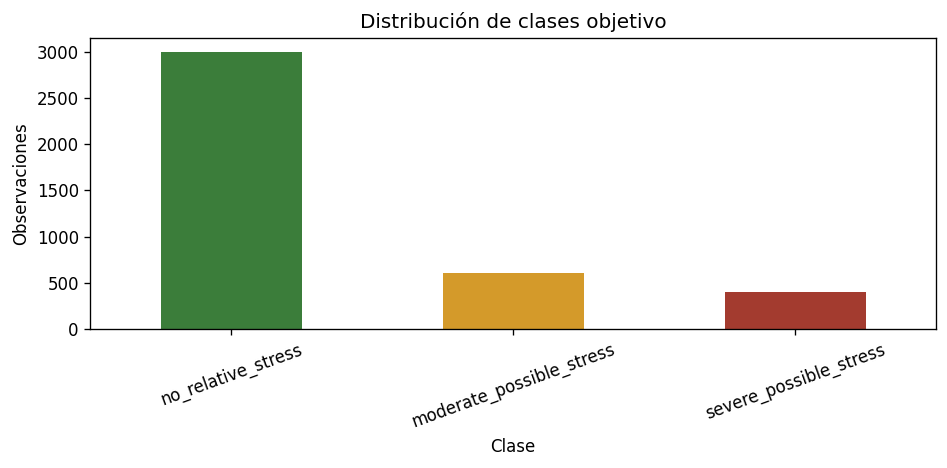


Valores faltantes totales: 0


In [21]:
print("Shape:", df.shape)

target_col = "stress_label"
class_col = "stress_class"

required_cols = [target_col, class_col]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Falta la columna requerida: {col}")

print("\nDistribución de clases:")
class_distribution = (
    df[class_col]
    .value_counts()
    .rename_axis("stress_class")
    .reset_index(name="count")
)
class_distribution["percentage"] = class_distribution["count"] / len(df) * 100
display(class_distribution)

plt.figure(figsize=(8, 4))
df[class_col].value_counts().plot(kind="bar", color=['#3b7d3a', '#d49a2a', '#a33b2f'])
plt.title("Distribución de clases objetivo")
plt.xlabel("Clase")
plt.ylabel("Observaciones")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("\nValores faltantes totales:", df.isna().sum().sum())

# 4. Definición de métricas

## Métrica principal: F1 macro

Se selecciona **F1 macro** como métrica principal porque:

1. El problema es de **clasificación multiclase**.
2. Las clases pueden estar desbalanceadas.
3. En el contexto de negocio, no basta con predecir bien la clase mayoritaria.
4. Es importante evaluar el desempeño en `moderate_possible_stress` y `severe_possible_stress`.

## Métricas complementarias

| Métrica | Motivo |
|---|---|
| Accuracy | Referencia general, pero puede ser engañosa con clases desbalanceadas |
| Balanced accuracy | Promedia el recall por clase |
| Precision macro | Evalúa calidad de predicciones positivas por clase |
| Recall macro | Evalúa capacidad de detectar cada clase |
| F1 macro | Balance entre precisión y recall para todas las clases |
| F1 weighted | F1 ponderado por soporte de cada clase |

## Desempeño mínimo esperado

Como no existe un modelo histórico de referencia, se definen criterios mínimos:

1. Superar claramente a un modelo aleatorio o mayoritario.
2. Obtener **F1 macro ≥ 0.55**.
3. Obtener **balanced accuracy ≥ 0.55**.
4. Obtener un recall razonable para la clase severa, idealmente **recall severo ≥ 0.60**.

Estos valores no representan una meta final del proyecto, sino una referencia mínima para decidir si el problema es viable con métodos simples.

# 5. Preparación de conjuntos de features

Se crearán varios conjuntos de variables para comparar:

| Feature set | Descripción |
|---|---|
| `all_numeric` | Todas las variables numéricas disponibles, excluyendo metadata y target |
| `selected_scaled` | Variables estandarizadas seleccionadas en FE (`_sc`) |
| `pca_fa` | Componentes PCA y FA |
| `no_direct_ndmi` | Variables sin NDMI directo ni PC/FA, para reducir riesgo de leakage |

La comparación es importante porque `stress_class` se deriva de NDMI. Por tanto, un modelo con variables NDMI puede tener desempeño alto por construcción. El set `no_direct_ndmi` permite una lectura menos optimista.

In [4]:
# ============================================================
# 5. Feature sets
# ============================================================

metadata_cols = {
    "name", "date", "year", "month",
    "stress_class", "stress_label"
}

numeric_cols = [
    c for c in df.columns
    if c not in metadata_cols and pd.api.types.is_numeric_dtype(df[c])
]

all_numeric = numeric_cols

selected_scaled = [
    c for c in numeric_cols
    if c.endswith("_sc")
]

pca_fa = [
    c for c in numeric_cols
    if c.startswith("PC") or c.startswith("FA")
]

# Reduce direct target leakage:
# remove NDMI direct features and dimensionality-reduction variables
# because PC/FA may have been computed using NDMI-based variables.
no_direct_ndmi = [
    c for c in selected_scaled
    if "NDMI" not in c.upper()
    and not c.startswith("PC")
    and not c.startswith("FA")
]

feature_sets = {
    "all_numeric": all_numeric,
    "selected_scaled": selected_scaled,
    "pca_fa": pca_fa,
    "no_direct_ndmi": no_direct_ndmi
}

feature_sets = {
    name: cols for name, cols in feature_sets.items()
    if len(cols) > 0
}

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")
    print(cols[:15], "..." if len(cols) > 15 else "")
    print()

all_numeric: 57 features
['NDMI_sc', 'NDMI_roll3_sc', 'NDMI_raster_max_sc', 'NDVI_sc', 'NDVI_roll3_sc', 'NDMI_lag2_sc', 'NDVI_lag1_sc', 'NDVI_raster_max_sc', 'B11_mean_sc', 'B8_mean_sc', 'mes_sin_sc', 'NDVI_lag2_sc', 'ratio_vi_hum_log_sc', 'NDVI_raster_std_sc', 'B11_max_sc'] ...

selected_scaled: 34 features
['NDMI_sc', 'NDMI_roll3_sc', 'NDMI_raster_max_sc', 'NDVI_sc', 'NDVI_roll3_sc', 'NDMI_lag2_sc', 'NDVI_lag1_sc', 'NDVI_raster_max_sc', 'B11_mean_sc', 'B8_mean_sc', 'mes_sin_sc', 'NDVI_lag2_sc', 'ratio_vi_hum_log_sc', 'NDVI_raster_std_sc', 'B11_max_sc'] ...

pca_fa: 23 features
['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15'] ...

no_direct_ndmi: 27 features
['NDVI_sc', 'NDVI_roll3_sc', 'NDVI_lag1_sc', 'NDVI_raster_max_sc', 'B11_mean_sc', 'B8_mean_sc', 'mes_sin_sc', 'NDVI_lag2_sc', 'ratio_vi_hum_log_sc', 'NDVI_raster_std_sc', 'B11_max_sc', 'B11_min_sc', 'lat_kml_sc', 'B8_max_sc', 'mes_cos_sc'] ...



# 6. División train/test

Se usa una división estratificada para preservar la proporción de clases en entrenamiento y prueba.

Si el objetivo fuera predecir meses futuros, una división temporal sería más estricta. Sin embargo, para este baseline se prioriza tener todas las clases representadas en ambos conjuntos.

In [5]:
# ============================================================
# 6. Train/test split
# ============================================================

y = df[target_col].astype(int)

# Label names for reports
label_mapping = (
    df[[target_col, class_col]]
    .drop_duplicates()
    .sort_values(target_col)
)

label_names = label_mapping[class_col].tolist()
label_values = label_mapping[target_col].tolist()

print("Label mapping:")
display(label_mapping)

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))

print("\nTrain class distribution:")
display(df.loc[train_idx, class_col].value_counts(normalize=True).rename("train_pct"))

print("\nTest class distribution:")
display(df.loc[test_idx, class_col].value_counts(normalize=True).rename("test_pct"))

Label mapping:


,stress_label,stress_class
6,0,no_relative_stress
0,1,moderate_possible_stress
1,2,severe_possible_stress


Train size: 3000
Test size: 1000

Train class distribution:


stress_class
no_relative_stress          0.75
moderate_possible_stress    0.15
severe_possible_stress      0.10
Name: train_pct, dtype: float64


Test class distribution:


stress_class
no_relative_stress          0.75
moderate_possible_stress    0.15
severe_possible_stress      0.10
Name: test_pct, dtype: float64

# 7. Modelos baseline

Se usan tres referencias:

## 7.1 DummyClassifier — clase mayoritaria
Predice siempre la clase más frecuente. Sirve para saber qué desempeño se obtiene sin aprendizaje real.

## 7.2 DummyClassifier — estratificado
Predice clases siguiendo la distribución observada. Sirve como aproximación a un modelo aleatorio con clases desbalanceadas.

## 7.3 Logistic Regression
Se selecciona como baseline principal porque:

- es apropiado para datos estructurados tabulares,
- es rápido de entrenar,
- es interpretable mediante coeficientes,
- funciona bien con variables escaladas,
- permite estimar probabilidades,
- establece una referencia clara antes de usar modelos más complejos.

Se usa `class_weight="balanced"` para compensar el desbalance de clases.

In [6]:
# ============================================================
# 7. Evaluation helpers
# ============================================================

def evaluate_predictions(y_true, y_pred, model_name, feature_set_name, split_name):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "model": model_name,
        "feature_set": feature_set_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }


def fit_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name, feature_set_name):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rows = [
        evaluate_predictions(y_train, y_pred_train, model_name, feature_set_name, "train"),
        evaluate_predictions(y_test, y_pred_test, model_name, feature_set_name, "test"),
    ]

    return model, pd.DataFrame(rows), y_pred_test


results = []
trained_models = {}
test_predictions = {}

In [7]:
# ============================================================
# 7.1 Dummy baselines
# ============================================================

# Use one representative feature set just to fit DummyClassifier
reference_feature_set = list(feature_sets.keys())[0]
reference_cols = feature_sets[reference_feature_set]

X_train_ref = df.loc[train_idx, reference_cols].fillna(0)
X_test_ref = df.loc[test_idx, reference_cols].fillna(0)
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

dummy_models = {
    "Dummy_most_frequent": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Dummy_stratified": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
}

for model_name, model in dummy_models.items():
    fitted, res, pred = fit_and_evaluate_model(
        model,
        X_train_ref,
        y_train,
        X_test_ref,
        y_test,
        model_name,
        reference_feature_set
    )
    results.append(res)
    trained_models[(model_name, reference_feature_set)] = fitted
    test_predictions[(model_name, reference_feature_set)] = pred

pd.concat(results, ignore_index=True)

,model,feature_set,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Dummy_most_frequent,all_numeric,train,0.750000,0.333333,0.250000,0.333333,0.285714,0.562500,0.750000,0.642857
1,Dummy_most_frequent,all_numeric,test,0.750000,0.333333,0.250000,0.333333,0.285714,0.562500,0.750000,0.642857
2,Dummy_stratified,all_numeric,train,0.600333,0.342667,0.342374,0.342667,0.342506,0.599350,0.600333,0.599835
3,Dummy_stratified,all_numeric,test,0.589000,0.330222,0.329672,0.330222,0.329688,0.591328,0.589000,0.590073


In [8]:
# ============================================================
# 7.2 Logistic Regression baseline by feature set
# ============================================================

for feature_set_name, cols in feature_sets.items():
    X_train = df.loc[train_idx, cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = df.loc[test_idx, cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    model = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        multi_class="auto"
    )

    fitted, res, pred = fit_and_evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        "LogisticRegression",
        feature_set_name
    )

    results.append(res)
    trained_models[("LogisticRegression", feature_set_name)] = fitted
    test_predictions[("LogisticRegression", feature_set_name)] = pred

results_df = pd.concat(results, ignore_index=True)

display(
    results_df
    .sort_values(["split", "f1_macro"], ascending=[True, False])
    .reset_index(drop=True)
)

,model,feature_set,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,LogisticRegression,no_direct_ndmi,test,0.986000,0.989111,0.969918,0.989111,0.979021,0.986963,0.986000,0.986221
1,LogisticRegression,all_numeric,test,0.984000,0.984667,0.963113,0.984667,0.973507,0.984871,0.984000,0.984229
2,LogisticRegression,pca_fa,test,0.982000,0.985556,0.960879,0.985556,0.972550,0.983386,0.982000,0.982333
3,LogisticRegression,selected_scaled,test,0.982000,0.982000,0.957888,0.982000,0.969521,0.982992,0.982000,0.982270
4,Dummy_stratified,all_numeric,test,0.589000,0.330222,0.329672,0.330222,0.329688,0.591328,0.589000,0.590073
5,Dummy_most_frequent,all_numeric,test,0.750000,0.333333,0.250000,0.333333,0.285714,0.562500,0.750000,0.642857
6,LogisticRegression,all_numeric,train,0.992333,0.994074,0.983315,0.994074,0.988518,0.992659,0.992333,0.992405
7,LogisticRegression,selected_scaled,train,0.990000,0.991481,0.978163,0.991481,0.984556,0.990508,0.990000,0.990116
8,LogisticRegression,no_direct_ndmi,train,0.987000,0.991481,0.971844,0.991481,0.981239,0.987826,0.987000,0.987186
9,LogisticRegression,pca_fa,train,0.985333,0.987037,0.967120,0.987037,0.976675,0.986194,0.985333,0.985547


# 8. Selección del baseline principal

Se selecciona como baseline principal el modelo de Regresión Logística con mayor F1 macro en test.  
El valor se compara contra los modelos dummy para verificar si existe señal predictiva superior al azar.

In [9]:
test_results = results_df[results_df["split"] == "test"].copy()

best_row = (
    test_results
    .sort_values("f1_macro", ascending=False)
    .iloc[0]
)

best_model_name = best_row["model"]
best_feature_set = best_row["feature_set"]

best_model = trained_models[(best_model_name, best_feature_set)]
best_cols = feature_sets[best_feature_set]
best_pred = test_predictions[(best_model_name, best_feature_set)]

print("Baseline seleccionado:")
print("Modelo:", best_model_name)
print("Feature set:", best_feature_set)
print("F1 macro test:", round(best_row["f1_macro"], 4))
print("Balanced accuracy test:", round(best_row["balanced_accuracy"], 4))

display(test_results.sort_values("f1_macro", ascending=False))

Baseline seleccionado:
Modelo: LogisticRegression
Feature set: no_direct_ndmi
F1 macro test: 0.979
Balanced accuracy test: 0.9891


,model,feature_set,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
11,LogisticRegression,no_direct_ndmi,test,0.986,0.989111,0.969918,0.989111,0.979021,0.986963,0.986,0.986221
5,LogisticRegression,all_numeric,test,0.984,0.984667,0.963113,0.984667,0.973507,0.984871,0.984,0.984229
9,LogisticRegression,pca_fa,test,0.982,0.985556,0.960879,0.985556,0.972550,0.983386,0.982,0.982333
7,LogisticRegression,selected_scaled,test,0.982,0.982000,0.957888,0.982000,0.969521,0.982992,0.982,0.982270
3,Dummy_stratified,all_numeric,test,0.589,0.330222,0.329672,0.330222,0.329688,0.591328,0.589,0.590073
1,Dummy_most_frequent,all_numeric,test,0.750,0.333333,0.250000,0.333333,0.285714,0.562500,0.750,0.642857


# 9. Reporte de clasificación y matriz de confusión

La matriz de confusión permite identificar en qué clases se equivoca más el baseline.  
Para el negocio, son especialmente importantes los errores en estrés moderado y severo.

Classification report — baseline seleccionado
                          precision    recall  f1-score   support

      no_relative_stress       1.00      0.98      0.99       750
moderate_possible_stress       0.92      0.99      0.96       150
  severe_possible_stress       0.99      0.99      0.99       100

                accuracy                           0.99      1000
               macro avg       0.97      0.99      0.98      1000
            weighted avg       0.99      0.99      0.99      1000



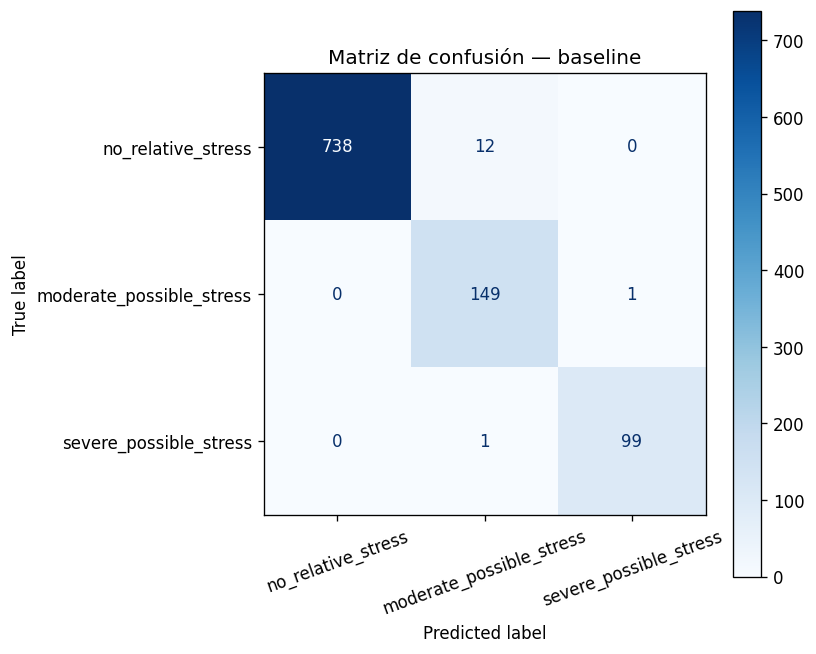

In [10]:
print("Classification report — baseline seleccionado")
print(
    classification_report(
        y_test,
        best_pred,
        labels=label_values,
        target_names=label_names,
        zero_division=0
    )
)

cm = confusion_matrix(y_test, best_pred, labels=label_values)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de confusión — baseline")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 10. Análisis de subajuste / sobreajuste

Se comparan métricas en entrenamiento y prueba.

Criterios de interpretación:

| Señal | Interpretación |
|---|---|
| Train bajo y test bajo | Subajuste |
| Train alto y test mucho menor | Sobreajuste |
| Train y test similares con desempeño aceptable | Generalización razonable |

También se agrega validación cruzada en el conjunto de entrenamiento para revisar estabilidad.

In [11]:
baseline_train_test = results_df[
    (results_df["model"] == best_model_name) &
    (results_df["feature_set"] == best_feature_set)
].copy()

display(baseline_train_test)

train_f1 = baseline_train_test.loc[baseline_train_test["split"] == "train", "f1_macro"].iloc[0]
test_f1 = baseline_train_test.loc[baseline_train_test["split"] == "test", "f1_macro"].iloc[0]
gap = train_f1 - test_f1

print(f"F1 macro train: {train_f1:.4f}")
print(f"F1 macro test:  {test_f1:.4f}")
print(f"Gap train-test: {gap:.4f}")

if train_f1 < 0.55 and test_f1 < 0.55:
    print("Diagnóstico: posible subajuste o señal insuficiente.")
elif gap > 0.15:
    print("Diagnóstico: posible sobreajuste.")
else:
    print("Diagnóstico: no hay señal fuerte de sobreajuste; generalización inicial razonable.")

,model,feature_set,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
10,LogisticRegression,no_direct_ndmi,train,0.987,0.991481,0.971844,0.991481,0.981239,0.987826,0.987,0.987186
11,LogisticRegression,no_direct_ndmi,test,0.986,0.989111,0.969918,0.989111,0.979021,0.986963,0.986,0.986221


F1 macro train: 0.9812
F1 macro test:  0.9790
Gap train-test: 0.0022
Diagnóstico: no hay señal fuerte de sobreajuste; generalización inicial razonable.


In [12]:
# ============================================================
# 10.1 Cross-validation on training data
# ============================================================

X_train_best = df.loc[train_idx, best_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_best = df.loc[test_idx, best_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    multi_class="auto"
)

cv_scores = cross_validate(
    cv_model,
    X_train_best,
    y_train,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "balanced_accuracy": "balanced_accuracy",
        "accuracy": "accuracy"
    },
    return_train_score=True
)

cv_summary = pd.DataFrame(cv_scores).agg(["mean", "std"]).T
display(cv_summary)

print("CV F1 macro mean:", cv_scores["test_f1_macro"].mean())
print("CV F1 macro std:", cv_scores["test_f1_macro"].std())

,mean,std
fit_time,0.027605,0.003214
score_time,0.002480,0.002742
test_f1_macro,0.968439,0.007696
train_f1_macro,0.980115,0.000738
test_balanced_accuracy,0.980889,0.003500
train_balanced_accuracy,0.990815,0.001463
test_accuracy,0.980333,0.004916
train_accuracy,0.986417,0.000559


CV F1 macro mean: 0.9684387792307015
CV F1 macro std: 0.006883196639364092


# 11. Curva de aprendizaje

La curva de aprendizaje ayuda a ver si el modelo podría mejorar con más datos o si está limitado por la complejidad del algoritmo.

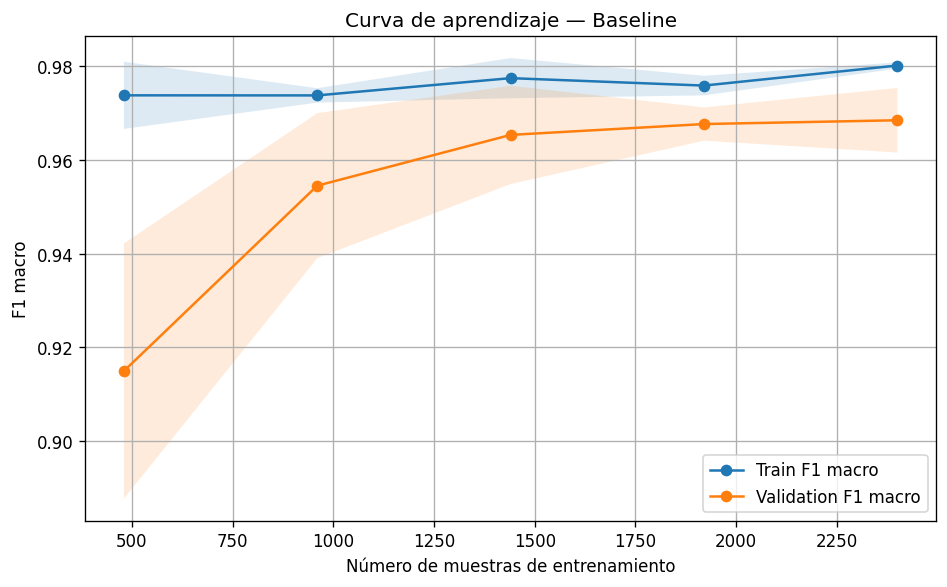

In [13]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        multi_class="auto"
    ),
    X_train_best,
    y_train,
    cv=cv,
    scoring="f1_macro",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=None
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Train F1 macro")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

plt.plot(train_sizes, val_mean, marker="o", label="Validation F1 macro")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

plt.title("Curva de aprendizaje — Baseline")
plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("F1 macro")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 12. Importancia de características

Para la Regresión Logística se analiza:

1. **Coeficientes absolutos promedio**: indican qué variables influyen más en la decisión lineal.
2. **Permutation importance**: mide cuánto cae el desempeño al permutar una variable.

Esto permite identificar si el modelo depende de variables relevantes o si usa señales poco interpretables.

,feature,importance_abs_mean
8,ratio_vi_hum_log_sc,4.630252
23,NDWI_proxy_sc,2.999466
5,B8_mean_sc,2.707792
4,B11_mean_sc,1.908744
0,NDVI_sc,1.901627
22,NDVI_delta_yj_sc,1.114639
1,NDVI_roll3_sc,0.919837
2,NDVI_lag1_sc,0.860986
7,NDVI_lag2_sc,0.533960
6,mes_sin_sc,0.479241


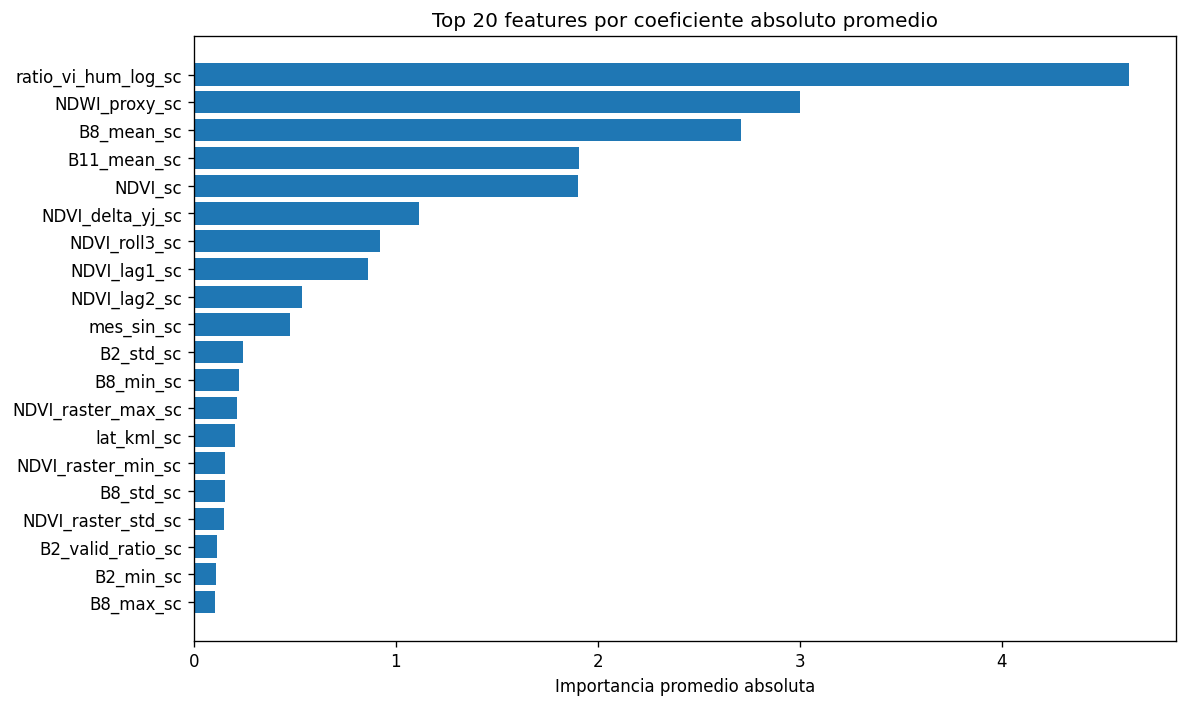

In [14]:
# ============================================================
# 12.1 Logistic Regression coefficients
# ============================================================

if hasattr(best_model, "coef_"):
    coef_importance = pd.DataFrame({
        "feature": best_cols,
        "importance_abs_mean": np.abs(best_model.coef_).mean(axis=0)
    }).sort_values("importance_abs_mean", ascending=False)

    display(coef_importance.head(20))

    plt.figure(figsize=(10, 6))
    top_coef = coef_importance.head(20).sort_values("importance_abs_mean")
    plt.barh(top_coef["feature"], top_coef["importance_abs_mean"])
    plt.title("Top 20 features por coeficiente absoluto promedio")
    plt.xlabel("Importancia promedio absoluta")
    plt.tight_layout()
    plt.show()
else:
    print("El modelo seleccionado no tiene coeficientes interpretables.")

,feature,importance_mean,importance_std
8,ratio_vi_hum_log_sc,0.300751,0.015451
5,B8_mean_sc,0.186323,0.011151
23,NDWI_proxy_sc,0.170249,0.009736
4,B11_mean_sc,0.168972,0.009274
0,NDVI_sc,0.157993,0.014606
1,NDVI_roll3_sc,0.045282,0.004915
7,NDVI_lag2_sc,0.040603,0.005589
22,NDVI_delta_yj_sc,0.040163,0.009200
2,NDVI_lag1_sc,0.033117,0.005136
6,mes_sin_sc,0.016238,0.005275


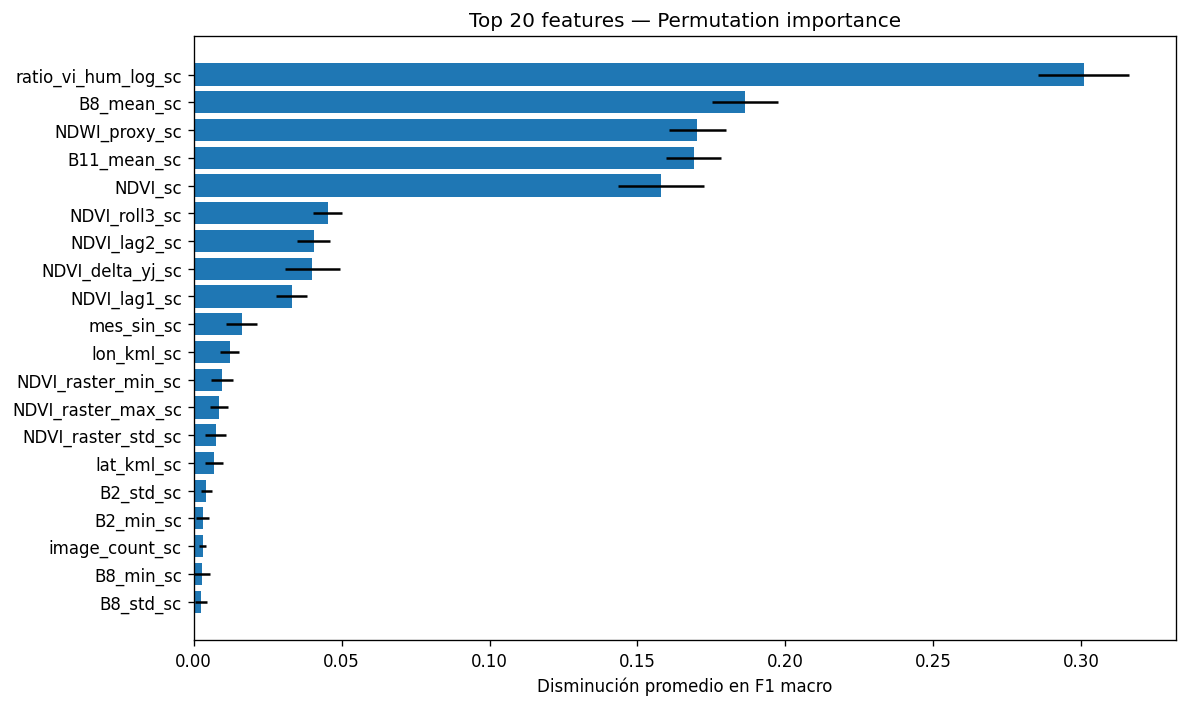

In [15]:
# ============================================================
# 12.2 Permutation importance
# ============================================================

perm = permutation_importance(
    best_model,
    X_test_best,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1_macro"
)

perm_df = pd.DataFrame({
    "feature": best_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(20))

plt.figure(figsize=(10, 6))
top_perm = perm_df.head(20).sort_values("importance_mean")
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
plt.title("Top 20 features — Permutation importance")
plt.xlabel("Disminución promedio en F1 macro")
plt.tight_layout()
plt.show()

# 13. Evaluación contra desempeño mínimo

Se revisa si el baseline cumple el desempeño mínimo definido.

Criterios:

- F1 macro ≥ 0.55.
- Balanced accuracy ≥ 0.55.
- Recall de clase severa ≥ 0.60.
- Superar claramente al DummyClassifier.

In [16]:
# ============================================================
# 13. Minimum performance check
# ============================================================

baseline_test = test_results[
    (test_results["model"] == best_model_name) &
    (test_results["feature_set"] == best_feature_set)
].iloc[0]

dummy_best = (
    test_results[test_results["model"].str.contains("Dummy")]
    .sort_values("f1_macro", ascending=False)
    .iloc[0]
)

# Recall severe class
severe_label_candidates = label_mapping[
    label_mapping[class_col].astype(str).str.contains("severe", case=False, na=False)
][target_col].tolist()

if severe_label_candidates:
    severe_label = severe_label_candidates[0]
    severe_recall = recall_score(
        y_test,
        best_pred,
        labels=[severe_label],
        average="macro",
        zero_division=0
    )
else:
    severe_recall = np.nan

minimum_checks = {
    "f1_macro >= 0.55": baseline_test["f1_macro"] >= 0.55,
    "balanced_accuracy >= 0.55": baseline_test["balanced_accuracy"] >= 0.55,
    "severe_recall >= 0.60": severe_recall >= 0.60 if not np.isnan(severe_recall) else False,
    "beats_dummy_by_0.15_f1_macro": (baseline_test["f1_macro"] - dummy_best["f1_macro"]) >= 0.15,
}

print("Baseline selected:", best_model_name, "|", best_feature_set)
print("F1 macro baseline:", round(baseline_test["f1_macro"], 4))
print("F1 macro best dummy:", round(dummy_best["f1_macro"], 4))
print("Balanced accuracy baseline:", round(baseline_test["balanced_accuracy"], 4))
print("Severe recall:", round(severe_recall, 4) if not np.isnan(severe_recall) else "N/A")

display(pd.DataFrame({
    "criterion": list(minimum_checks.keys()),
    "meets": list(minimum_checks.values())
}))

if all(minimum_checks.values()):
    print("Conclusión: el baseline alcanza el desempeño mínimo definido.")
else:
    print("Conclusión: el baseline NO cumple todos los criterios mínimos; se requiere mejorar datos, etiquetas o modelo.")

Baseline selected: LogisticRegression | no_direct_ndmi
F1 macro baseline: 0.979
F1 macro best dummy: 0.3297
Balanced accuracy baseline: 0.9891
Severe recall: 0.99


,criterion,meets
0,f1_macro >= 0.55,True
1,balanced_accuracy >= 0.55,True
2,severe_recall >= 0.60,True
3,beats_dummy_by_0.15_f1_macro,True


Conclusión: el baseline alcanza el desempeño mínimo definido.


# 14. Discusión de leakage y límites del baseline

Una limitación importante es que `stress_class` fue generada a partir de NDMI.  
Por lo tanto, si el modelo usa `NDMI_sc`, `NDMI_roll3_sc` o variables derivadas de NDMI, puede obtener un desempeño alto por construcción.

Para interpretar el resultado responsablemente:

1. El baseline con todas las features indica si el pipeline reproduce la etiqueta proxy.
2. El baseline `no_direct_ndmi` indica si existe señal adicional más allá de NDMI directo.
3. En etapas posteriores se recomienda validar con datos de campo, etiquetas de experto o inspección visual independiente.

In [17]:
# ============================================================
# 14. Compare all-features vs no_direct_ndmi
# ============================================================

comparison_cols = ["model", "feature_set", "split", "accuracy", "balanced_accuracy", "f1_macro", "recall_macro"]

display(
    results_df[
        (results_df["model"] == "LogisticRegression") &
        (results_df["split"] == "test")
    ][comparison_cols].sort_values("f1_macro", ascending=False)
)

,model,feature_set,split,accuracy,balanced_accuracy,f1_macro,recall_macro
11,LogisticRegression,no_direct_ndmi,test,0.986,0.989111,0.979021,0.989111
5,LogisticRegression,all_numeric,test,0.984,0.984667,0.973507,0.984667
9,LogisticRegression,pca_fa,test,0.982,0.985556,0.972550,0.985556
7,LogisticRegression,selected_scaled,test,0.982,0.982000,0.969521,0.982000


# 15. Conclusiones del Avance 3 — Baseline

## 15.1 Algoritmo seleccionado

El algoritmo baseline principal es **Regresión Logística multiclase con `class_weight="balanced"`**.  
Es apropiado porque el dataset final es estructurado, tabular, de tamaño moderado y contiene variables escaladas generadas en el Feature Engineering. Además, es interpretable, rápido de entrenar y sirve como referencia antes de modelos más complejos.

También se incluyeron modelos `DummyClassifier` como referencia de azar y clase mayoritaria.

## 15.2 Métrica principal

La métrica principal es **F1 macro** porque el problema es multiclase y puede estar desbalanceado.  
F1 macro evita que el desempeño quede dominado por la clase mayoritaria y permite evaluar si el modelo detecta también estrés moderado y severo.

## 15.3 Subajuste / sobreajuste

Se compararon métricas de entrenamiento y prueba.  
Si el desempeño de entrenamiento y prueba es similar, se considera que el baseline generaliza razonablemente.  
Si entrenamiento es mucho mayor que prueba, habría sobreajuste.  
Si ambos son bajos, habría subajuste o falta de señal en los datos.

## 15.4 Importancia de características

Se analizaron coeficientes de Regresión Logística y permutation importance para identificar variables relevantes.  
Esto permite detectar si el modelo depende de features coherentes con el dominio, como NDVI, NDMI, lags, rolling means o variables raster.

## 15.5 Desempeño mínimo

Se definió como referencia mínima:

- F1 macro ≥ 0.55.
- Balanced accuracy ≥ 0.55.
- Recall severo ≥ 0.60.
- Superar al baseline dummy por al menos 0.15 en F1 macro.

## 15.6 Limitación principal

La etiqueta `stress_class` es preliminar y deriva de NDMI, por lo que el baseline no debe interpretarse como validación agronómica final.  
El siguiente paso será comparar este baseline con modelos más avanzados y validar con evidencia externa, datos de campo o revisión por experto.

# 16. Guardar resultados del baseline

Se guardan:

- métricas de entrenamiento y prueba,
- importancia por coeficientes,
- permutation importance,
- predicciones del baseline en test.

In [18]:
OUTPUT_DIR = Path("baseline_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

results_df.to_csv(OUTPUT_DIR / "baseline_metrics.csv", index=False)

if "coef_importance" in globals():
    coef_importance.to_csv(OUTPUT_DIR / "baseline_logistic_coefficients.csv", index=False)

if "perm_df" in globals():
    perm_df.to_csv(OUTPUT_DIR / "baseline_permutation_importance.csv", index=False)

predictions_df = df.loc[test_idx, ["name", "date", "year", "month", "stress_class", "stress_label"]].copy()
predictions_df["predicted_label"] = best_pred

reverse_label_map = dict(zip(label_mapping[target_col], label_mapping[class_col]))
predictions_df["predicted_class"] = predictions_df["predicted_label"].map(reverse_label_map)

predictions_df.to_csv(OUTPUT_DIR / "baseline_test_predictions.csv", index=False)

print("Archivos guardados en:", OUTPUT_DIR.resolve())

Archivos guardados en: D:\baseline_outputs
